# Interactive Multiround AMR Testing Notebook

**Purpose:** Manual exploration, debugging, and verification of the multi-round sequential DRL-AMR environment (`DGAMREnvMultiround`).

This notebook provides an interactive widget interface to:
- Step through the priority queue one element at a time, choosing actions (Coarsen/Hold/Refine)
- See action masks — which actions are structurally valid for the current element
- Observe dual reward signals (local shaping per step, global retrospective per interval)
- Track error classification against α-based thresholds (under-refined / neutral / over-refined)
- Monitor queue priority ordering and element error indicators
- Auto-complete rounds or entire remesh intervals with do-nothing actions
- Visualize mesh state, solution, error distribution, and reward/resource history

**Architecture:** The environment presents elements in priority-queue order. The user only chooses an action — element selection is handled by the environment. Solver advance happens automatically at remesh interval boundaries.

**Episode Structure:**
```
Episode (N_remesh remesh intervals)
  └─ Remesh Interval (max_level rounds + solver advance + global reward)
       └─ Adaptation Round (single pass over all active elements)
            └─ Element Visit (observe → decide → execute → local reward)
```

**Usage:**
1. Run all cells
2. The current element and its action mask are displayed automatically
3. Choose an action (Coarsen/Hold/Refine) — invalid actions are greyed out
4. Click "Step" to execute and see results
5. Use "Auto-complete Round" or "Auto-complete Interval" to fast-forward
6. Adjust settings (α, budget, icase, etc.) and click "Apply Settings" to restart

**Note:** This is a debugging/verification tool, not part of the production workflow.


In [1]:
#==========================================================
#         ----------  Cell One ------------
#==========================================================
"""
Cell 1: Imports and Configuration
Sets up the environment, imports required modules, and configures matplotlib for SVG output.
"""
import os
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import clear_output
from IPython.display import display as ipython_display

# =====================================================================
# Configure matplotlib for SVG output
# =====================================================================
matplotlib.rcParams['savefig.format'] = 'svg'
matplotlib.rcParams['svg.fonttype'] = 'none'    # Keep fonts as text (not paths)
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.transparent'] = False

# =====================================================================
# Add project root to path for imports
# =====================================================================
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

# =====================================================================
# Project imports — multiround architecture
# =====================================================================
from numerical.solvers.dg_advection_solver_multiround import DGAdvectionSolver
from numerical.environments.dg_amr_env_multiround import DGAMREnvMultiround
from numerical.solvers.error_indicators import (
    compute_element_errors,
    compute_alpha_thresholds,
    compute_normalized_error,
)

# =====================================================================
# Action name mapping for display
# Maps action indices to human-readable labels
#   0 = Coarsen, 1 = Hold (do-nothing), 2 = Refine
# =====================================================================
ACTION_NAMES = {0: "Coarsen", 1: "Hold", 2: "Refine"}

# =====================================================================
# Color scheme for action types and error classification
# Used consistently across console output and plots
# =====================================================================
ACTION_COLORS = {
    "Coarsen": "red",
    "Hold": "blue",
    "Refine": "green",
    "Timestep": "purple",       # Solver advance (interval boundary)
}

CLASSIFICATION_COLORS = {
    "UNDER": "red",             # e_k > e_max — needs refinement
    "NEUTRAL": "green",         # e_min <= e_k <= e_max — acceptable
    "OVER": "blue",             # e_k < e_min — over-refined
}

# =====================================================================
# Available initial conditions for the icase dropdown
# Includes ICs with negative values to test for u > 0 bias
# =====================================================================
IC_OPTIONS = {
    1:  "Gaussian pulse",
    10: "Tanh smooth square",
    12: "Sigmoid smooth square",
    13: "Multi-Gaussian",
    14: "Bump function",
    15: "Sech² soliton",
    16: "Mexican hat (Ricker)",
}

In [3]:
#==========================================================
#         ----------  Cell Two ------------
#==========================================================
"""
Cell 2: InteractiveMultiroundTester Class — Infrastructure

Defines the class skeleton: constructor, environment creation, widget setup,
and utility methods. Action handlers (Cell 3) and visualization (Cell 4)
are defined separately and attached to the class.

The tester wraps DGAMREnvMultiround and provides an interactive notebook
interface for manual exploration. The environment presents elements in
priority-queue order; the user only chooses the action.

Key differences from InteractiveAMRTester (old architecture):
    - Element selection is automatic (queue order), not user-controlled
    - Action masking displayed (MaskablePPO-aware)
    - Dual reward: local shaping per step + global retrospective per interval
    - Nested episode structure: intervals × rounds × elements
    - Error classification against α-based thresholds
    - No "Take Timestep" — solver advance is automatic at interval boundaries

Dependencies (from Cell 1):
    - numpy as np
    - matplotlib.pyplot as plt, patches, gridspec
    - ipywidgets as widgets
    - IPython.display: clear_output, display (as ipython_display)
    - DGAdvectionSolver from numerical.solvers.dg_advection_solver_multiround
    - DGAMREnvMultiround from numerical.environments.dg_amr_env_multiround
    - compute_element_errors, compute_alpha_thresholds, compute_normalized_error
    - ACTION_NAMES, ACTION_COLORS, CLASSIFICATION_COLORS, IC_OPTIONS
"""


class InteractiveMultiroundTester:
    """Interactive widget-based tester for the multi-round DRL-AMR environment.

    Provides a Jupyter notebook interface for manually stepping through
    the DGAMREnvMultiround environment. The environment presents elements
    in priority-queue order; the user chooses actions (Coarsen/Hold/Refine).

    Key features:
        - Action mask display (shows which actions are structurally valid)
        - Queue priority and error classification display
        - Dual reward tracking (local shaping + global retrospective)
        - Episode structure visualization (intervals, rounds, queue position)
        - Auto-complete round/interval with do-nothing actions
        - Configurable parameters (α, β, rewards, budget, IC selection)

    Widget Layout:
        +------------------------------------------------------+
        |  Status Bar (interval, round, queue pos, mask)       |
        +------------------------------------------------------+
        |  [Action Radio]  | [Auto-R] [Auto-I]  | [Settings]  |
        |  [Step Button ]  | [Reset ] [SVG    ]  | [Sliders ]  |
        |                  |                      | [Apply   ]  |
        +------------------------------------------------------+
        |  Mesh State (element levels + highlighting)          |
        +------------------------------------------------------+
        |  Solution Plot (current + previous)                  |
        +------------------------------------------------------+
        |  Error Classification (bar chart + thresholds)       |
        +------------------------------------------------------+
        |  Action Hist | Reward Hist | Resource Usage           |
        +------------------------------------------------------+
        |  Console Output (scrollable, captures env verbosity) |
        +------------------------------------------------------+

    Attributes:
        env (DGAMREnvMultiround): The wrapped Gymnasium environment.
        solver (DGAdvectionSolver): Shortcut to env.solver.
        obs (np.ndarray): Current observation (8 components).
        episode_done (bool): Whether current episode has terminated.
        step_log (list): List of (action, reward, terminated, info) dicts.
        previous_solution (np.ndarray): Solution before last action.
        previous_coord (np.ndarray): Coordinates before last action.
        auto_save_svg (bool): Auto-export SVG after each render.
        current_fig (Figure): Current matplotlib figure for SVG export.
    """

    def __init__(
        self,
        nop=4,
        initial_elements=np.array([-1, -0.5, 0, 0.5, 1]),
        max_level=3,
        element_budget=30,
        alpha=0.1,
        beta=1.2,
        p_ur=10.0,
        p_or=5.0,
        p_cr=2.0,
        lambda_local=0.1,
        n_remesh=4,
        step_domain_fraction=0.05,
        initial_refinement_level=0,
        icase=1,
    ):
        """Initialize the interactive multiround tester.

        Creates the solver, environment, history tracking, and all
        interactive widgets. Calls reset() on the environment and
        displays the initial queue with priorities.

        Args:
            nop: Polynomial order for DG basis (default 4 → 5 LGL nodes).
            initial_elements: Base mesh boundary coordinates.
            max_level: Maximum refinement level. Also determines rounds
                per remesh interval (D-018).
            element_budget: Soft cap on active elements.
            alpha: Error tolerance (0 < α < 1). Smaller → more refinement.
            beta: Hysteresis exponent (β > 1). Wider neutral zone.
            p_ur: Under-refinement penalty weight.
            p_or: Over-refinement penalty weight.
            p_cr: Correct coarsening reward weight (D-020).
            lambda_local: Local-to-global reward weighting.
            n_remesh: Remesh intervals per episode.
            step_domain_fraction: Fraction of domain per remesh interval.
            initial_refinement_level: Uniform refinement passes at start.
                0 = base mesh (4 elements), 1 = 8 elements, etc.
            icase: Initial condition (1=Gaussian, 10=Tanh, etc.).
        """
        # =====================================================================
        # Store configuration parameters
        # =====================================================================
        self.nop = nop
        self.initial_elements = initial_elements
        self.max_level = max_level
        self.element_budget = element_budget
        self.alpha = alpha
        self.beta = beta
        self.p_ur = p_ur
        self.p_or = p_or
        self.p_cr = p_cr
        self.lambda_local = lambda_local
        self.n_remesh = n_remesh
        self.step_domain_fraction = step_domain_fraction
        self.initial_refinement_level = initial_refinement_level
        self.icase = icase

        # =====================================================================
        # Create solver and environment, perform initial reset
        # Sets: self.solver, self.env, self.obs, self.episode_done
        # =====================================================================
        self.create_environment()

        # =====================================================================
        # Initialize step log for history tracking
        # Each entry is a dict with: action, action_name, reward,
        # terminated, and all keys from the env's info dict.
        # Replaces the old tester's parallel history lists with a
        # single unified log — plotting extracts what it needs.
        # =====================================================================
        self.step_log = []

        # =====================================================================
        # Previous solution state for visualization comparison
        # Updated before each step; shown as dashed reference line
        # =====================================================================
        self.previous_solution = self.env.solver.q.copy()
        self.previous_coord = self.env.solver.coord.copy()

        # =====================================================================
        # Auto-save SVG flag
        # =====================================================================
        self.auto_save_svg = False
        self.current_fig = None

        # =====================================================================
        # Create console output widget (scrollable text area)
        # All print output — including env verbosity=2 narrative —
        # is directed here via 'with self.output_area:' contexts
        # =====================================================================
        self.output_area = widgets.Output(
            layout={
                'border': '1px solid #ccc',
                'padding': '10px',
                'height': '300px',
                'overflow_y': 'auto',
                'font-family': 'monospace',
                'background-color': '#f9f9f9',
                'margin-top': '10px',
            }
        )

        # =====================================================================
        # Create interactive control widgets
        # =====================================================================
        self.setup_widgets()

        # =====================================================================
        # Welcome message and initial queue display
        # =====================================================================
        with self.output_area:
            print("=== Multiround AMR Testing Console ===")
            print(f"IC: {IC_OPTIONS.get(self.icase, '?')} (icase={self.icase})")
            print(f"Elements: {len(self.env.solver.active)}/{self.element_budget}")
            print(f"Thresholds: e_max={self.env.e_max:.6e}, e_min={self.env.e_min:.6e}")
            print()
        self._display_queue_info()
        self._update_status_display()

    def console_print(self, *args, **kwargs):
        """Print to the notebook output widget.

        Redirects output to the scrollable output_area widget,
        keeping messages contained within the notebook interface.

        Args:
            *args: Positional arguments passed to print().
            **kwargs: Keyword arguments passed to print().
        """
        with self.output_area:
            print(*args, **kwargs)

    def create_environment(self):
        """Create the DG solver and multiround RL environment.

        Instantiates a DGAdvectionSolver with balance=False (the
        environment handles balance enforcement for cascade tracking),
        wraps it in DGAMREnvMultiround with verbosity=2, and performs
        the initial reset.

        Side Effects:
            Sets: self.solver, self.env, self.obs, self.episode_done
        """
        # =====================================================================
        # Create the DG advection solver
        # balance=False — environment handles balance for cascade tracking
        # max_elements = 4x budget as safety headroom
        # =====================================================================
        self.solver = DGAdvectionSolver(
            nop=self.nop,
            xelem=self.initial_elements,
            max_elements=self.element_budget * 4,
            max_level=self.max_level,
            courant_max=0.1,
            icase=self.icase,
            verbose=False,       # env handles logging, not solver
            balance=False,       # env handles balance explicitly
        )

        # =====================================================================
        # Create the multiround RL environment
        # verbosity=2: full step-level narrative in console
        # ic_pool doesn't matter — we force icase via reset options
        # =====================================================================
        self.env = DGAMREnvMultiround(
            solver=self.solver,
            element_budget=self.element_budget,
            alpha=self.alpha,
            beta=self.beta,
            p_ur=self.p_ur,
            p_or=self.p_or,
            p_cr=self.p_cr,
            lambda_local=self.lambda_local,
            n_remesh=self.n_remesh,
            step_domain_fraction=self.step_domain_fraction,
            initial_refinement_level=self.initial_refinement_level,
            ic_pool=[self.icase],
            verbosity=2,
        )

        # =====================================================================
        # Reset environment with explicit IC and refinement level
        # Captures env's verbosity=2 output in console widget if available
        # =====================================================================
        if hasattr(self, 'output_area'):
            with self.output_area:
                self.obs, self.info = self.env.reset(options={
                    'icase': self.icase,
                    'refinement_level': self.initial_refinement_level,
                })
        else:
            # First call from __init__ before output_area exists
            self.obs, self.info = self.env.reset(options={
                'icase': self.icase,
                'refinement_level': self.initial_refinement_level,
            })

        self.episode_done = False

    def setup_widgets(self):
        """Create and configure all interactive control widgets.

        Widget groups:
            Action controls: action radio, step button
            Navigation: auto-complete round/interval, reset, SVG save
            Settings: all environment parameters, apply button
            Status: HTML widget for position/mask display

        Side Effects:
            Sets all widget attributes and arranges them in layout containers.
        """
        # =====================================================================
        # Status bar — HTML widget showing current position and mask
        # Updated by _update_status_display() after each step
        # =====================================================================
        self.status_html = widgets.HTML(
            value="<i>Initializing...</i>",
            layout={'margin': '0 0 10px 0'},
        )

        # =====================================================================
        # Action selection — RadioButtons for Coarsen/Hold/Refine
        # Values map directly to env.step() action indices (0, 1, 2)
        # Invalid actions shown in status bar; blocked in on_step()
        # =====================================================================
        self.action_radio = widgets.RadioButtons(
            options=[('Coarsen (0)', 0), ('Hold (1)', 1), ('Refine (2)', 2)],
            value=1,             # Default to Hold
            description='Action:',
            disabled=False,
        )

        # =====================================================================
        # Step button — execute one env.step() with selected action
        # =====================================================================
        self.step_button = widgets.Button(
            description='Step',
            button_style='success',
            tooltip='Execute selected action on the current element',
        )
        self.step_button.on_click(self.on_step)

        # =====================================================================
        # Auto-complete Round — loop do-nothing through remaining queue
        # =====================================================================
        self.auto_round_button = widgets.Button(
            description='Auto Round',
            button_style='primary',
            tooltip='Complete current round with Hold actions',
        )
        self.auto_round_button.on_click(self.on_auto_complete_round)

        # =====================================================================
        # Auto-complete Interval — all remaining rounds with do-nothing
        # Triggers solver advance + global reward at boundary
        # =====================================================================
        self.auto_interval_button = widgets.Button(
            description='Auto Interval',
            button_style='primary',
            tooltip='Complete current interval with Hold actions (triggers solver advance)',
        )
        self.auto_interval_button.on_click(self.on_auto_complete_interval)

        # =====================================================================
        # Reset button — restart episode with current settings
        # =====================================================================
        self.reset_button = widgets.Button(
            description='Reset',
            button_style='warning',
            tooltip='Reset environment to start a new episode',
        )
        self.reset_button.on_click(self.on_reset)

        # =====================================================================
        # Save SVG button and auto-save checkbox
        # =====================================================================
        self.save_button = widgets.Button(
            description='Save SVG',
            button_style='',
            tooltip='Save current plot as SVG file',
        )
        self.save_button.on_click(lambda b: self.save_current_plot_svg())

        self.auto_save_checkbox = widgets.Checkbox(
            value=False,
            description='Auto-save SVG',
            tooltip='Automatically save SVG after each render',
        )
        self.auto_save_checkbox.observe(self.on_auto_save_changed, names='value')

        # =====================================================================
        # Settings widgets — environment parameters
        # Applied via on_apply_settings which recreates solver + env
        # =====================================================================

        # IC selection dropdown
        self.icase_dropdown = widgets.Dropdown(
            options=[(f"{v} ({k})", k) for k, v in IC_OPTIONS.items()],
            value=self.icase,
            description='IC:',
        )

        # Initial refinement level
        self.refinement_slider = widgets.IntSlider(
            min=0, max=self.max_level, step=1,
            value=self.initial_refinement_level,
            description='Init Ref:',
            continuous_update=False,
        )

        # Alpha (error tolerance)
        self.alpha_slider = widgets.FloatSlider(
            min=0.01, max=0.5, step=0.01,
            value=self.alpha,
            description='α:',
            readout_format='.2f',
            continuous_update=False,
        )

        # Beta (hysteresis exponent)
        self.beta_slider = widgets.FloatSlider(
            min=1.0, max=2.0, step=0.05,
            value=self.beta,
            description='β:',
            readout_format='.2f',
            continuous_update=False,
        )

        # Element budget
        self.budget_slider = widgets.IntSlider(
            min=10, max=60, step=5,
            value=self.element_budget,
            description='Budget:',
            continuous_update=False,
        )

        # Lambda (local-to-global weighting)
        self.lambda_slider = widgets.FloatSlider(
            min=0.01, max=1.0, step=0.01,
            value=self.lambda_local,
            description='λ_local:',
            readout_format='.2f',
            continuous_update=False,
        )

        # p_cr (coarsening reward)
        self.p_cr_slider = widgets.FloatSlider(
            min=0.0, max=10.0, step=0.5,
            value=self.p_cr,
            description='p_cr:',
            readout_format='.1f',
            continuous_update=False,
        )

        # N_remesh (intervals per episode)
        self.n_remesh_slider = widgets.IntSlider(
            min=1, max=8, step=1,
            value=self.n_remesh,
            description='N_remesh:',
            continuous_update=False,
        )

        # Apply settings button
        self.settings_button = widgets.Button(
            description='Apply Settings',
            button_style='info',
            tooltip='Apply new settings (resets environment)',
        )
        self.settings_button.on_click(self.on_apply_settings)

        # =====================================================================
        # Layout arrangement
        # =====================================================================

        # Left column: action selection and step
        action_box = widgets.VBox([
            self.action_radio,
            self.step_button,
        ])

        # Middle column: navigation and utilities
        nav_box = widgets.VBox([
            self.auto_round_button,
            self.auto_interval_button,
            self.reset_button,
            self.save_button,
            self.auto_save_checkbox,
        ])

        # Right column: settings
        settings_box = widgets.VBox([
            self.icase_dropdown,
            self.refinement_slider,
            self.alpha_slider,
            self.beta_slider,
            self.budget_slider,
            self.lambda_slider,
            self.p_cr_slider,
            self.n_remesh_slider,
            self.settings_button,
        ])

        # Main control row
        self.control_box = widgets.HBox(
            [action_box, nav_box, settings_box],
            layout={'margin': '10px 0'},
        )

    # =========================================================================
    # Utility Methods
    # =========================================================================

    def _classify_element(self, error, e_max, e_min):
        """Classify an element's error against α-based thresholds.

        Args:
            error: Raw error indicator for the element.
            e_max: Upper threshold (under-refinement boundary).
            e_min: Lower threshold (over-refinement boundary).

        Returns:
            str: 'UNDER', 'NEUTRAL', or 'OVER'.
        """
        eps = 1e-30
        if error > e_max and e_max > eps:
            return "UNDER"
        elif error < e_min and e_min > eps:
            return "OVER"
        else:
            return "NEUTRAL"

    def _display_queue_info(self):
        """Display the current priority queue with errors and classifications.

        Recomputes priorities externally using the same logic as
        env._build_queue() for transparency. Shows a table with:
        position, element ID, raw error, priority magnitude, and
        classification (UNDER/NEUTRAL/OVER).

        The current queue position is marked with ◀.
        """
        # =====================================================================
        # Compute current errors and get thresholds from env
        # =====================================================================
        errors = compute_element_errors(self.env.solver)
        e_max = self.env.e_max
        e_min = self.env.e_min
        eps = 1e-30

        # =====================================================================
        # Print queue header
        # =====================================================================
        self.console_print(
            f"\n  Priority Queue — Round {self.env.round_number}/"
            f"{self.env.solver.max_level}, "
            f"Interval {self.env.remesh_step + 1}/{self.env.n_remesh}"
        )
        self.console_print(
            f"  Thresholds: e_max={e_max:.4e}, e_min={e_min:.4e}"
        )
        self.console_print(
            f"  {'Pos':>4} | {'ElemID':>6} | {'Error':>12} | "
            f"{'Priority':>8} | {'Class':>7}"
        )
        self.console_print(f"  {'-'*4}-+-{'-'*6}-+-{'-'*12}-+-{'-'*8}-+-{'-'*7}")

        # =====================================================================
        # Print each queue entry with priority and classification
        # =====================================================================
        for pos, elem_id in enumerate(self.env.queue):
            # Find element in active list
            matches = np.where(self.env.solver.active == elem_id)[0]
            if len(matches) == 0:
                self.console_print(
                    f"  {pos+1:>4} | {elem_id:>6} | {'(consumed)':>12} | "
                    f"{'---':>8} | {'---':>7}"
                )
                continue

            idx = int(matches[0])
            e_k = errors[idx]

            # Compute priority (mirrors _build_queue logic)
            e_k_safe = max(e_k, eps)
            if e_k_safe > e_max and e_max > eps:
                priority = np.log10(e_k_safe / e_max)
                classification = "UNDER"
            elif e_k_safe < e_min and e_min > eps:
                priority = np.log10(e_min / e_k_safe)
                classification = "OVER"
            else:
                priority = 0.0
                classification = "NEUTRAL"

            # Mark current position
            marker = " ◀" if pos == self.env.queue_position else ""
            self.console_print(
                f"  {pos+1:>4} | {elem_id:>6} | {e_k:>12.4e} | "
                f"{priority:>8.4f} | {classification:>7}{marker}"
            )

        self.console_print()

    def _update_status_display(self):
        """Update the status bar HTML widget with current position and mask.

        Shows: interval, round, queue position, element ID, level,
        and action mask with check/cross indicators.
        """
        if self.episode_done:
            self.status_html.value = (
                '<b style="color: purple;">EPISODE COMPLETE</b> — '
                'Click Reset to start a new episode'
            )
            return

        # =====================================================================
        # Read current state from environment
        # =====================================================================
        elem_id = int(self.env.solver.active[self.env.current_element_idx])
        level = self.env._get_element_level(self.env.current_element_idx)
        mask = self.env.action_masks()

        # =====================================================================
        # Format mask with color-coded check/cross
        # =====================================================================
        def _mask_span(label, valid):
            if valid:
                return f'<span style="color:green;">✓{label}</span>'
            else:
                return f'<span style="color:red;text-decoration:line-through;">✗{label}</span>'

        mask_str = (
            f"{_mask_span('C', mask[0])} "
            f"{_mask_span('H', mask[1])} "
            f"{_mask_span('R', mask[2])}"
        )

        # =====================================================================
        # Classify current element for display
        # =====================================================================
        errors = compute_element_errors(self.env.solver)
        e_k = errors[self.env.current_element_idx]
        classification = self._classify_element(e_k, self.env.e_max, self.env.e_min)
        class_color = CLASSIFICATION_COLORS.get(classification, 'black')

        # =====================================================================
        # Assemble status HTML
        # =====================================================================
        self.status_html.value = (
            f"<b>Interval {self.env.remesh_step + 1}/{self.env.n_remesh}</b> · "
            f"<b>Round {self.env.round_number}/{self.env.solver.max_level}</b> · "
            f"Queue {self.env.queue_position + 1}/{len(self.env.queue)} · "
            f"Elem <b>{elem_id}</b> (idx {self.env.current_element_idx}, "
            f"L{level}) · "
            f'<span style="color:{class_color};"><b>{classification}</b></span> · '
            f"Mask: [{mask_str}] · "
            f"Step {len(self.step_log) + 1}"
        )

    def save_current_plot_svg(self, filename=None):
        """Save the current figure as SVG vector graphics.

        Args:
            filename: Output filename. If None, auto-generates with timestamp.

        Returns:
            str: Filename if successful, None otherwise.
        """
        import time
        if filename is None:
            filename = f'multiround_amr_{int(time.time())}.svg'

        if self.current_fig is not None:
            self.current_fig.savefig(filename, format='svg', bbox_inches='tight')
            self.console_print(f"Saved as {filename}")
            return filename
        else:
            self.console_print("No current figure available to save")
            return None

    def debug_data_structures(self):
        """Print debug info about solver and environment internal state.

        Useful for verifying element indexing, queue state, and
        threshold values during manual testing.
        """
        self.console_print("\n=== Debug: Solver State ===")
        self.console_print(f"  active: {list(self.env.solver.active)}")
        self.console_print(f"  n_active: {len(self.env.solver.active)}")
        self.console_print(f"  time: {self.env.solver.time:.6f}")
        self.console_print(f"  xelem[:5]: {self.env.solver.xelem[:5]}")

        self.console_print("\n=== Debug: Environment State ===")
        self.console_print(f"  remesh_step: {self.env.remesh_step}/{self.env.n_remesh}")
        self.console_print(f"  round_number: {self.env.round_number}/{self.env.solver.max_level}")
        self.console_print(f"  queue_position: {self.env.queue_position}/{len(self.env.queue)}")
        self.console_print(f"  current_element_idx: {self.env.current_element_idx}")
        self.console_print(f"  episode_steps: {self.env._episode_steps}")
        self.console_print(f"  e_max: {self.env.e_max:.6e}")
        self.console_print(f"  e_min: {self.env.e_min:.6e}")
        self.console_print(f"  consumed_elements: {self.env.consumed_elements}")
        self.console_print(f"  queue (elem IDs): {self.env.queue}")
        self.console_print(f"  episode_done: {self.episode_done}")

        # Per-element levels
        levels = [self.env._get_element_level(i)
                  for i in range(len(self.env.solver.active))]
        self.console_print(f"  levels: {levels}")
        self.console_print()

    def on_auto_save_changed(self, change):
        """Callback when auto-save checkbox is toggled.

        Args:
            change: ipywidgets change dict with 'new' value.
        """
        self.auto_save_svg = change['new']
        self.console_print(
            f"Auto-save SVG: {'enabled' if self.auto_save_svg else 'disabled'}"
        )

In [4]:
#==========================================================
#         ----------  Cell Three ------------
#==========================================================
"""
Cell 3: Action Handlers

Defines the callback methods for all interactive buttons:
    - on_step: Execute one env.step() with the selected action
    - on_auto_complete_round: Hold through remaining queue in current round
    - on_auto_complete_interval: Hold through all remaining rounds + solver advance
    - on_reset: Reset environment to start a new episode
    - on_apply_settings: Recreate environment with new parameter values

These are attached to the class defined in Cell 2. Each handler:
    1. Captures pre-action state for visualization
    2. Wraps env calls in 'with self.output_area:' to capture verbosity=2 output
    3. Appends to self.step_log
    4. Updates status display
    5. Calls self.render() to refresh plots and widgets

Dependencies:
    - InteractiveMultiroundTester class (Cell 2)
    - ACTION_NAMES, IC_OPTIONS (Cell 1)
    - compute_element_errors, compute_alpha_thresholds (Cell 1)
"""


def _on_step(self, b):
    """Callback for the Step button — execute one agent decision.

    Reads the selected action from the radio widget, validates it
    against the current action mask, executes env.step(), logs the
    result, and updates the display.

    On interval-terminal steps (transition='interval' or 'done'),
    the environment internally advances the solver and computes the
    global retrospective reward. This method detects that from the
    info dict and displays the new queue for the next interval.

    Args:
        b: Button widget (required by ipywidgets, not used).
    """
    # =====================================================================
    # Guard: episode already complete
    # =====================================================================
    if self.episode_done:
        self.console_print("Episode is complete. Click Reset to start a new episode.")
        return

    # =====================================================================
    # Read selected action and validate against mask
    # =====================================================================
    action = self.action_radio.value
    mask = self.env.action_masks()

    if not mask[action]:
        self.console_print(
            f"\n  ✗ Action {ACTION_NAMES[action]} is MASKED for this element. "
            f"Choose a valid action."
        )
        return

    # =====================================================================
    # Capture pre-action state for visualization
    # Solution and coordinates saved as "previous" reference line
    # =====================================================================
    self.previous_solution = self.env.solver.q.copy()
    self.previous_coord = self.env.solver.coord.copy()

    # =====================================================================
    # Execute env.step() with verbosity=2 output captured in console
    # =====================================================================
    with self.output_area:
        obs, reward, terminated, truncated, info = self.env.step(action)

    self.obs = obs

    # =====================================================================
    # Append to step log — unified history for all plotting
    # =====================================================================
    entry = {
        'action': action,
        'action_name': ACTION_NAMES[action],
        'reward': reward,
        'terminated': terminated,
    }
    entry.update(info)
    self.step_log.append(entry)

    # =====================================================================
    # Print step summary to console
    # =====================================================================
    transition = info.get('transition', 'element')
    r_local_scaled = self.lambda_local * info.get('r_local', 0)
    r_global = info.get('r_global', 0)
    global_str = f", global={r_global:.4f}" if r_global != 0 else ""

    self.console_print(
        f"\n  Step {len(self.step_log)}: {ACTION_NAMES[action]} on elem "
        f"{info.get('element_id', '?')} → reward={reward:.4f} "
        f"(λ·local={r_local_scaled:.4f}{global_str})"
    )

    if info.get('n_cascade', 0) > 0:
        self.console_print(
            f"    ⚡ {info['n_cascade']} cascade element(s) created by balance enforcement"
        )

    # =====================================================================
    # Handle transitions
    # =====================================================================
    if terminated:
        self.episode_done = True
        self.console_print("\n  ═══ EPISODE COMPLETE ═══")
        self.console_print(f"  Total steps: {len(self.step_log)}")
        total_reward = sum(e['reward'] for e in self.step_log)
        self.console_print(f"  Total reward: {total_reward:.4f}")

    elif transition == 'interval':
        # =================================================================
        # New interval started — show solver advance info and new queue
        # =================================================================
        self.console_print(
            f"\n  ── Interval boundary: solver advanced "
            f"T={info.get('solver_T', 0):.6f}, "
            f"{info.get('solver_n_steps', 0)} sub-steps ──"
        )
        self._display_queue_info()

    elif transition == 'element' and info.get('round_number', 0) != self._last_round():
        # =================================================================
        # Round transition happened inside _advance_queue
        # The round_number in info reflects the NEW round
        # =================================================================
        self.console_print(
            f"\n  ── Round transition → Round {info.get('round_number', '?')}"
            f"/{self.env.solver.max_level} ──"
        )
        self._display_queue_info()

    # =====================================================================
    # Update display
    # =====================================================================
    self._update_status_display()
    self.render()


def _last_round(self):
    """Get the round number from the previous step log entry.

    Used to detect round transitions (current round != previous round).

    Returns:
        Round number from previous step, or 1 if no previous step.
    """
    if len(self.step_log) >= 2:
        return self.step_log[-2].get('round_number', 1)
    return 1


def _on_auto_complete_round(self, b):
    """Callback for Auto Round — hold through remaining queue.

    Executes Hold (action=1) repeatedly until either:
    - A round transition occurs (queue exhausted, next round begins)
    - An interval transition occurs (last round complete, solver advances)
    - Episode terminates

    Verbosity is temporarily reduced to 1 (summary) during the loop
    to avoid flooding the console. A summary is printed at the end.

    Args:
        b: Button widget (required by ipywidgets, not used).
    """
    # =====================================================================
    # Guard: episode already complete
    # =====================================================================
    if self.episode_done:
        self.console_print("Episode is complete. Click Reset to start a new episode.")
        return

    # =====================================================================
    # Capture starting state for summary
    # =====================================================================
    start_round = self.env.round_number
    start_step_count = len(self.step_log)

    self.console_print(f"\n  Auto-completing round {start_round}...")

    # =====================================================================
    # Save pre-round solution for visualization
    # =====================================================================
    self.previous_solution = self.env.solver.q.copy()
    self.previous_coord = self.env.solver.coord.copy()

    # =====================================================================
    # Reduce verbosity during bulk actions
    # =====================================================================
    old_verbosity = self.env.verbosity
    self.env.verbosity = 1

    # =====================================================================
    # Loop: Hold actions until transition
    # =====================================================================
    steps_taken = 0
    final_transition = 'element'

    with self.output_area:
        while not self.episode_done:
            obs, reward, terminated, truncated, info = self.env.step(1)
            self.obs = obs

            entry = {
                'action': 1,
                'action_name': 'Hold',
                'reward': reward,
                'terminated': terminated,
            }
            entry.update(info)
            self.step_log.append(entry)
            steps_taken += 1

            transition = info.get('transition', 'element')
            final_transition = transition

            if terminated:
                self.episode_done = True
                break

            # =============================================================
            # Stop conditions: round changed or interval boundary
            # =============================================================
            if transition == 'interval':
                break
            if self.env.round_number != start_round:
                break

    # =====================================================================
    # Restore verbosity
    # =====================================================================
    self.env.verbosity = old_verbosity

    # =====================================================================
    # Print summary
    # =====================================================================
    rewards = [e['reward'] for e in self.step_log[start_step_count:]]
    total_r = sum(rewards)

    self.console_print(
        f"  Auto-round complete: {steps_taken} steps, "
        f"total reward={total_r:.4f}"
    )

    if final_transition == 'interval':
        self.console_print(
            f"  ── Interval boundary: solver advanced ──"
        )
        self._display_queue_info()
    elif final_transition == 'done':
        self.console_print("\n  ═══ EPISODE COMPLETE ═══")
    else:
        self._display_queue_info()

    if self.episode_done:
        total_reward = sum(e['reward'] for e in self.step_log)
        self.console_print(f"  Total episode reward: {total_reward:.4f}")

    # =====================================================================
    # Update display
    # =====================================================================
    self._update_status_display()
    self.render()


def _on_auto_complete_interval(self, b):
    """Callback for Auto Interval — hold through all remaining rounds.

    Executes Hold (action=1) repeatedly until either:
    - An interval transition occurs (all rounds complete, solver advances)
    - Episode terminates

    This completes all remaining rounds in the current remesh interval,
    triggering solver advance and global retrospective reward at the end.

    Verbosity is temporarily reduced to 1 during the loop.

    Args:
        b: Button widget (required by ipywidgets, not used).
    """
    # =====================================================================
    # Guard: episode already complete
    # =====================================================================
    if self.episode_done:
        self.console_print("Episode is complete. Click Reset to start a new episode.")
        return

    # =====================================================================
    # Capture starting state for summary
    # =====================================================================
    start_interval = self.env.remesh_step
    start_step_count = len(self.step_log)

    self.console_print(
        f"\n  Auto-completing interval {start_interval + 1}/{self.env.n_remesh}..."
    )

    # =====================================================================
    # Save pre-interval solution for visualization
    # =====================================================================
    self.previous_solution = self.env.solver.q.copy()
    self.previous_coord = self.env.solver.coord.copy()

    # =====================================================================
    # Reduce verbosity during bulk actions
    # =====================================================================
    old_verbosity = self.env.verbosity
    self.env.verbosity = 1

    # =====================================================================
    # Loop: Hold actions until interval boundary or episode end
    # =====================================================================
    steps_taken = 0
    global_reward = 0.0

    with self.output_area:
        while not self.episode_done:
            obs, reward, terminated, truncated, info = self.env.step(1)
            self.obs = obs

            entry = {
                'action': 1,
                'action_name': 'Hold',
                'reward': reward,
                'terminated': terminated,
            }
            entry.update(info)
            self.step_log.append(entry)
            steps_taken += 1

            transition = info.get('transition', 'element')

            if info.get('r_global', 0) != 0:
                global_reward = info['r_global']

            if terminated:
                self.episode_done = True
                break

            if transition == 'interval':
                break

    # =====================================================================
    # Restore verbosity
    # =====================================================================
    self.env.verbosity = old_verbosity

    # =====================================================================
    # Print summary
    # =====================================================================
    rewards = [e['reward'] for e in self.step_log[start_step_count:]]
    total_r = sum(rewards)

    self.console_print(
        f"  Auto-interval complete: {steps_taken} steps, "
        f"total reward={total_r:.4f} "
        f"(global={global_reward:.4f})"
    )

    if self.episode_done:
        self.console_print("\n  ═══ EPISODE COMPLETE ═══")
        total_reward = sum(e['reward'] for e in self.step_log)
        self.console_print(f"  Total episode reward: {total_reward:.4f}")
    else:
        self._display_queue_info()

    # =====================================================================
    # Update display
    # =====================================================================
    self._update_status_display()
    self.render()


def _on_reset(self, b):
    """Callback for Reset — start a new episode with current settings.

    Resets the environment, clears the step log, and refreshes
    the display. Uses the icase and refinement level from the
    current widget values (not just stored attributes), so the
    user can change IC or refinement level without clicking
    Apply Settings first.

    Args:
        b: Button widget (required by ipywidgets, not used).
    """
    # =====================================================================
    # Read current IC and refinement from widgets
    # (allows quick IC switching without full Apply Settings)
    # =====================================================================
    self.icase = self.icase_dropdown.value
    self.initial_refinement_level = self.refinement_slider.value

    self.console_print(
        f"\n  Resetting: icase={self.icase} "
        f"({IC_OPTIONS.get(self.icase, '?')}), "
        f"init_ref={self.initial_refinement_level}..."
    )

    # =====================================================================
    # Reset the environment with explicit IC and refinement level
    # Solver reset handles icase switching internally
    # =====================================================================
    self.env.solver.icase = self.icase

    with self.output_area:
        self.obs, self.info = self.env.reset(options={
            'icase': self.icase,
            'refinement_level': self.initial_refinement_level,
        })

    # =====================================================================
    # Clear state
    # =====================================================================
    self.episode_done = False
    self.step_log = []
    self.previous_solution = self.env.solver.q.copy()
    self.previous_coord = self.env.solver.coord.copy()

    # =====================================================================
    # Display initial state
    # =====================================================================
    self.console_print(
        f"  Elements: {len(self.env.solver.active)}/{self.element_budget}"
    )
    self.console_print(
        f"  Thresholds: e_max={self.env.e_max:.6e}, "
        f"e_min={self.env.e_min:.6e}"
    )
    self._display_queue_info()

    # =====================================================================
    # Update display
    # =====================================================================
    self._update_status_display()
    self.render()
    self.console_print("  Reset complete.\n")


def _on_apply_settings(self, b):
    """Callback for Apply Settings — recreate environment with new values.

    Reads all settings widgets, updates instance attributes, recreates
    the solver and environment from scratch, clears history, and
    refreshes the display.

    This is a full teardown-and-rebuild. Use Reset for quick IC/refinement
    changes that don't require new solver or reward parameters.

    Args:
        b: Button widget (required by ipywidgets, not used).
    """
    # =====================================================================
    # Read all widget values
    # =====================================================================
    self.icase = self.icase_dropdown.value
    self.initial_refinement_level = self.refinement_slider.value
    self.alpha = self.alpha_slider.value
    self.beta = self.beta_slider.value
    self.element_budget = self.budget_slider.value
    self.lambda_local = self.lambda_slider.value
    self.p_cr = self.p_cr_slider.value
    self.n_remesh = self.n_remesh_slider.value

    self.console_print(
        f"\n  Applying settings: icase={self.icase}, "
        f"init_ref={self.initial_refinement_level}, "
        f"α={self.alpha}, β={self.beta}, budget={self.element_budget}, "
        f"λ={self.lambda_local}, p_cr={self.p_cr}, N_remesh={self.n_remesh}"
    )

    # =====================================================================
    # Recreate solver and environment with new parameters
    # =====================================================================
    self.create_environment()

    # =====================================================================
    # Clear state
    # =====================================================================
    self.episode_done = False
    self.step_log = []
    self.previous_solution = self.env.solver.q.copy()
    self.previous_coord = self.env.solver.coord.copy()

    # =====================================================================
    # Display initial state
    # =====================================================================
    self.console_print(
        f"  Elements: {len(self.env.solver.active)}/{self.element_budget}"
    )
    self.console_print(
        f"  Thresholds: e_max={self.env.e_max:.6e}, "
        f"e_min={self.env.e_min:.6e}"
    )
    self._display_queue_info()

    # =====================================================================
    # Update display
    # =====================================================================
    self._update_status_display()
    self.render()
    self.console_print("  Settings applied.\n")


# =========================================================================
# Attach methods to the class
# =========================================================================
InteractiveMultiroundTester.on_step = _on_step
InteractiveMultiroundTester._last_round = _last_round
InteractiveMultiroundTester.on_auto_complete_round = _on_auto_complete_round
InteractiveMultiroundTester.on_auto_complete_interval = _on_auto_complete_interval
InteractiveMultiroundTester.on_reset = _on_reset
InteractiveMultiroundTester.on_apply_settings = _on_apply_settings

In [5]:
#==========================================================
#         ----------  Cell Four ------------
#==========================================================
"""
Cell 4: Visualization — render() and all plot methods

Figure layout (4 rows × 3 columns via GridSpec):
    Row 0 (full width): Mesh State — elements as rectangles, levels, highlighting
    Row 1 (full width): Solution Plot — current + previous solution
    Row 2 (full width): Error Classification — bar chart with threshold lines
    Row 3 (3 panels):   Action History | Reward History | Resource Usage

Also defines show_tester(), the main entry point.

Dependencies:
    - InteractiveMultiroundTester class (Cells 2-3)
    - matplotlib.pyplot, patches, gridspec (Cell 1)
    - ipywidgets, clear_output, ipython_display (Cell 1)
    - ACTION_NAMES, ACTION_COLORS, CLASSIFICATION_COLORS (Cell 1)
    - compute_element_errors (Cell 1)
"""


def _render(self):
    """Render the current state with all visualizations.

    Creates a matplotlib figure with 7 subplots, displays it along
    with the status bar, control widgets, and console output.

    Called after every action, auto-complete, reset, or settings change.

    Layout:
        Row 0: Mesh state (element levels + highlighting)
        Row 1: Solution plot (current + previous)
        Row 2: Error classification (bar chart + thresholds)
        Row 3: Action history | Reward history | Resource usage

    Side Effects:
        - Clears previous cell output
        - Creates and displays matplotlib figure
        - Stores figure in self.current_fig for SVG export
        - Displays status bar, control widgets, and console output
    """
    # =====================================================================
    # Clear previous output to prevent stacking
    # =====================================================================
    clear_output(wait=True)

    # =====================================================================
    # Create figure with GridSpec layout
    # 4 rows × 3 columns:
    #   Row 0: mesh state (spans all 3)
    #   Row 1: solution (spans all 3)
    #   Row 2: error classification (spans all 3)
    #   Row 3: three history panels (1 each)
    # =====================================================================
    fig = plt.figure(figsize=(18, 16))
    gs = gridspec.GridSpec(
        4, 3, figure=fig,
        height_ratios=[1.0, 1.0, 0.8, 0.8],
    )

    ax_mesh = fig.add_subplot(gs[0, :])
    self.plot_mesh_state(ax_mesh)

    ax_sol = fig.add_subplot(gs[1, :])
    self.plot_solution(ax_sol)

    ax_err = fig.add_subplot(gs[2, :])
    self.plot_error_classification(ax_err)

    ax_act = fig.add_subplot(gs[3, 0])
    self.plot_action_history(ax_act)

    ax_rew = fig.add_subplot(gs[3, 1])
    self.plot_reward_history(ax_rew)

    ax_res = fig.add_subplot(gs[3, 2])
    self.plot_resource_history(ax_res)

    plt.tight_layout()
    ipython_display(fig)
    plt.close(fig)

    self.current_fig = fig

    # =====================================================================
    # Auto-save SVG if enabled
    # =====================================================================
    if self.auto_save_svg:
        self.save_current_plot_svg()

    # =====================================================================
    # Display widgets below the figure
    # =====================================================================
    main_layout = widgets.VBox([
        self.status_html,
        self.control_box,
        widgets.HTML("<h4>Console Output:</h4>"),
        self.output_area,
    ])
    ipython_display(main_layout)


def _plot_mesh_state(self, ax):
    """Plot the current mesh state showing element levels and IDs.

    Elements shown as rectangles:
        - Width = physical element size
        - Height = refinement level
        - Color: lightblue (normal), orange (current element),
                 yellow (cascade-created this round)
        - Element ID labeled above each rectangle

    Args:
        ax: Matplotlib Axes to draw on.
    """
    active = self.env.solver.active
    n_active = len(active)

    # =====================================================================
    # Current element index for highlighting
    # =====================================================================
    current_idx = self.env.current_element_idx if not self.episode_done else -1

    # =====================================================================
    # Cascade elements for yellow highlighting
    # =====================================================================
    cascade_ids = self.env.consumed_elements

    # =====================================================================
    # Draw each element as a rectangle
    # =====================================================================
    for i, elem_id in enumerate(active):
        level = int(self.env.solver.label_mat[elem_id - 1][4])
        x_left = self.env.solver.info_mat[elem_id - 1][-2]
        x_right = self.env.solver.info_mat[elem_id - 1][-1]
        width = x_right - x_left
        center = (x_left + x_right) / 2

        # =================================================================
        # Determine face color
        # =================================================================
        if i == current_idx:
            facecolor = 'orange'
        elif elem_id in cascade_ids:
            facecolor = 'khaki'
        else:
            facecolor = 'lightblue'

        rect = patches.Rectangle(
            (x_left, 0), width, max(level, 0.15),
            linewidth=1.5,
            edgecolor='blue',
            facecolor=facecolor,
            alpha=0.7,
        )
        ax.add_patch(rect)

        # =================================================================
        # Element ID label above rectangle
        # =====================================================================
        is_current = (i == current_idx)
        ax.text(
            center, level + 0.12, str(elem_id),
            ha='center', va='bottom', fontsize=9,
            color='darkred' if is_current else 'black',
            fontweight='bold' if is_current else 'normal',
        )

    # =====================================================================
    # Domain boundaries and axes
    # =====================================================================
    xelem = self.env.solver.xelem
    ax.axvline(xelem[0], color='black', linestyle='-')
    ax.axvline(xelem[-1], color='black', linestyle='-')

    ax.set_xlim(xelem[0] - 0.1, xelem[-1] + 0.1)
    ax.set_ylim(0, self.max_level + 0.5)
    ax.set_ylabel('Refinement Level')
    ax.set_xlabel('x coordinate')
    ax.set_title(
        f'Mesh State — {n_active}/{self.element_budget} elements | '
        f'time={self.env.solver.time:.4f}'
    )
    ax.grid(True, alpha=0.3)

    # =====================================================================
    # Legend for highlighting colors
    # =====================================================================
    legend_patches = [
        patches.Patch(facecolor='orange', edgecolor='blue', label='Current element'),
        patches.Patch(facecolor='khaki', edgecolor='blue', label='Cascade (this round)'),
        patches.Patch(facecolor='lightblue', edgecolor='blue', label='Normal'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=8)


def _plot_solution(self, ax):
    """Plot current solution with previous solution as reference.

    Shows:
        - Current solution (solid blue)
        - Previous solution (dashed magenta) — before last action
        - Element boundaries (gray dashed vertical lines)
        - Current element region highlighted (orange shading)

    Args:
        ax: Matplotlib Axes to draw on.
    """
    # =====================================================================
    # Plot previous solution as dashed reference
    # =====================================================================
    if self.previous_solution is not None and self.previous_coord is not None:
        ax.plot(
            self.previous_coord, self.previous_solution,
            color='darkmagenta', ls='--', linewidth=2.0, alpha=0.7,
            label='Previous Solution',
        )

    # =====================================================================
    # Plot current solution
    # =====================================================================
    x = self.env.solver.coord
    q = self.env.solver.q
    ax.plot(x, q, 'b-', linewidth=2, label='Current Solution')

    # =====================================================================
    # Element boundaries as dashed lines
    # =====================================================================
    active = self.env.solver.active
    for elem_id in active:
        x_left = self.env.solver.info_mat[elem_id - 1][-2]
        ax.axvline(x_left, color='gray', linestyle='--', alpha=0.3)
    # Right boundary of last element
    last_id = active[-1]
    ax.axvline(
        self.env.solver.info_mat[last_id - 1][-1],
        color='gray', linestyle='--', alpha=0.3,
    )

    # =====================================================================
    # Highlight current element region
    # =====================================================================
    if not self.episode_done:
        current_id = active[self.env.current_element_idx]
        x_left = self.env.solver.info_mat[current_id - 1][-2]
        x_right = self.env.solver.info_mat[current_id - 1][-1]
        ax.axvspan(x_left, x_right, alpha=0.2, color='orange')

    # =====================================================================
    # Axes configuration
    # =====================================================================
    xelem = self.env.solver.xelem
    ax.set_xlim(xelem[0], xelem[-1])
    ax.set_xlabel('x coordinate')
    ax.set_ylabel('Solution (q)')
    ax.set_title('Solution')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)


def _plot_error_classification(self, ax):
    """Plot per-element error indicators with classification thresholds.

    Bar chart where:
        - Each bar = one active element's error indicator
        - Color = classification: red (UNDER), green (NEUTRAL), blue (OVER)
        - Horizontal lines at e_max and e_min thresholds
        - Current element bar has black edge highlight

    Args:
        ax: Matplotlib Axes to draw on.
    """
    # =====================================================================
    # Compute errors and classify each element
    # =====================================================================
    errors = compute_element_errors(self.env.solver)
    active = self.env.solver.active
    n_active = len(active)
    e_max = self.env.e_max
    e_min = self.env.e_min

    # =====================================================================
    # Build bar data
    # =====================================================================
    x_positions = np.arange(n_active)
    bar_colors = []
    edge_colors = []

    current_idx = self.env.current_element_idx if not self.episode_done else -1

    for i in range(n_active):
        classification = self._classify_element(errors[i], e_max, e_min)
        bar_colors.append(CLASSIFICATION_COLORS.get(classification, 'gray'))
        edge_colors.append('black' if i == current_idx else 'none')

    # =====================================================================
    # Draw bars
    # =====================================================================
    bars = ax.bar(
        x_positions, errors, color=bar_colors,
        edgecolor=edge_colors, linewidth=2.0,
    )

    # =====================================================================
    # Element ID labels on x-axis
    # =====================================================================
    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [str(int(eid)) for eid in active],
        fontsize=8, rotation=45 if n_active > 12 else 0,
    )

    # =====================================================================
    # Threshold lines
    # =====================================================================
    if e_max > 0:
        ax.axhline(
            e_max, color='red', linestyle='--', linewidth=1.5,
            label=f'e_max = {e_max:.4e}',
        )
    if e_min > 0:
        ax.axhline(
            e_min, color='blue', linestyle='--', linewidth=1.5,
            label=f'e_min = {e_min:.4e}',
        )

    # =====================================================================
    # Axes configuration
    # =====================================================================
    ax.set_xlabel('Element ID')
    ax.set_ylabel('Error Indicator')
    ax.set_title(
        f'Error Classification (α={self.alpha}, β={self.beta})'
    )
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

    # =====================================================================
    # Use log scale if error range spans more than 2 orders of magnitude
    # =====================================================================
    if len(errors) > 0:
        e_range = errors[errors > 0]
        if len(e_range) > 0 and np.max(e_range) / np.min(e_range) > 100:
            ax.set_yscale('log')


def _plot_action_history(self, ax):
    """Plot history of actions as colored bars.

    Each step shown as a colored bar:
        - Green = Refine, Red = Coarsen, Blue = Hold
    Round and interval boundaries marked with vertical lines.

    Args:
        ax: Matplotlib Axes to draw on.
    """
    # =====================================================================
    # Empty history
    # =====================================================================
    if not self.step_log:
        ax.text(0.5, 0.5, "No actions yet", ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title('Action History')
        ax.set_xticks([])
        ax.set_yticks([])
        return

    # =====================================================================
    # Build bars
    # =====================================================================
    n = len(self.step_log)
    step_nums = np.arange(1, n + 1)
    colors = [ACTION_COLORS.get(e['action_name'], 'gray') for e in self.step_log]

    ax.bar(step_nums, [1] * n, color=colors, width=1.0, edgecolor='none')

    # =====================================================================
    # Mark interval boundaries with thick black lines
    # Mark round boundaries with thin gray lines
    # =====================================================================
    prev_interval = 0
    prev_round = 1

    for i, entry in enumerate(self.step_log):
        curr_interval = entry.get('remesh_step', 0)
        curr_round = entry.get('round_number', 1)

        if curr_interval != prev_interval and i > 0:
            ax.axvline(i + 0.5, color='black', linewidth=2.0, linestyle='-')
        elif curr_round != prev_round and i > 0:
            ax.axvline(i + 0.5, color='gray', linewidth=1.0, linestyle='--')

        prev_interval = curr_interval
        prev_round = curr_round

    # =====================================================================
    # Axes configuration
    # =====================================================================
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0.5, n + 0.5)
    ax.set_xlabel('Step')
    ax.set_title('Action History')
    ax.set_yticks([])

    # =====================================================================
    # Compact legend
    # =====================================================================
    legend_patches = [
        patches.Patch(color=ACTION_COLORS['Refine'], label='Refine'),
        patches.Patch(color=ACTION_COLORS['Hold'], label='Hold'),
        patches.Patch(color=ACTION_COLORS['Coarsen'], label='Coarsen'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=7)


def _plot_reward_history(self, ax):
    """Plot reward history showing dual decomposition.

    Shows:
        - Green bars: λ * r_local component
        - Orange bars: r_global component (only on interval-terminal steps)
        - Black line: total reward
        - y=0 reference line

    Args:
        ax: Matplotlib Axes to draw on.
    """
    # =====================================================================
    # Empty history
    # =====================================================================
    if not self.step_log:
        ax.text(0.5, 0.5, "No rewards yet", ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title('Reward History')
        ax.set_xticks([])
        ax.set_yticks([])
        return

    # =====================================================================
    # Extract reward components
    # =====================================================================
    n = len(self.step_log)
    step_nums = np.arange(1, n + 1)

    local_component = np.array([
        self.lambda_local * e.get('r_local', 0) for e in self.step_log
    ])
    global_component = np.array([
        e.get('r_global', 0) for e in self.step_log
    ])
    total_reward = np.array([e['reward'] for e in self.step_log])

    # =====================================================================
    # Stacked bars: local on bottom, global on top
    # =====================================================================
    ax.bar(step_nums, local_component, color='green', alpha=0.7,
           label=f'λ·local (λ={self.lambda_local})', width=0.8)
    ax.bar(step_nums, global_component, bottom=local_component,
           color='orange', alpha=0.7, label='global', width=0.8)

    # =====================================================================
    # Total reward line
    # =====================================================================
    ax.plot(step_nums, total_reward, 'ko-', markersize=3,
            linewidth=1.0, label='Total')

    # =====================================================================
    # Reference line at y=0
    # =====================================================================
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)

    # =====================================================================
    # Mark interval boundaries
    # =====================================================================
    prev_interval = 0
    for i, entry in enumerate(self.step_log):
        curr_interval = entry.get('remesh_step', 0)
        if curr_interval != prev_interval and i > 0:
            ax.axvline(i + 0.5, color='black', linewidth=1.5, linestyle='-')
        prev_interval = curr_interval

    # =====================================================================
    # Axes configuration
    # =====================================================================
    ax.set_xlabel('Step')
    ax.set_ylabel('Reward')
    ax.set_title('Reward Components')
    ax.legend(loc='upper left', fontsize=7)
    ax.set_xlim(0.5, n + 0.5)
    ax.grid(True, axis='y', alpha=0.3)


def _plot_resource_history(self, ax):
    """Plot resource usage (element count / budget) over steps.

    Shows:
        - Blue line: resource usage after each step
        - Red dashed line: budget limit (1.0)
        - Element count annotated above each data point (sparse for readability)

    Args:
        ax: Matplotlib Axes to draw on.
    """
    # =====================================================================
    # Empty history
    # =====================================================================
    if not self.step_log:
        ax.text(0.5, 0.5, "No data yet", ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title('Resource Usage')
        ax.set_xticks([])
        ax.set_yticks([])
        return

    # =====================================================================
    # Extract resource usage from step log
    # =====================================================================
    n = len(self.step_log)
    step_nums = np.arange(1, n + 1)
    resource_usage = np.array([
        e.get('resource_usage', 0) for e in self.step_log
    ])
    n_active_post = np.array([
        e.get('n_active_post', 0) for e in self.step_log
    ])

    # =====================================================================
    # Plot resource usage line
    # =====================================================================
    ax.plot(step_nums, resource_usage, 'bo-', markersize=3, linewidth=1.0,
            label='Resource usage')

    # =====================================================================
    # Budget limit reference line
    # =====================================================================
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5,
               label='Budget limit')

    # =====================================================================
    # Annotate element counts (every Nth point for readability)
    # =====================================================================
    annotation_interval = max(1, n // 15)
    for i in range(0, n, annotation_interval):
        ax.text(
            step_nums[i], resource_usage[i] + 0.02,
            str(int(n_active_post[i])),
            ha='center', va='bottom', fontsize=7,
        )
    # Always annotate the last point
    if n > 1 and (n - 1) % annotation_interval != 0:
        ax.text(
            step_nums[-1], resource_usage[-1] + 0.02,
            str(int(n_active_post[-1])),
            ha='center', va='bottom', fontsize=7,
        )

    # =====================================================================
    # Mark interval boundaries
    # =====================================================================
    prev_interval = 0
    for i, entry in enumerate(self.step_log):
        curr_interval = entry.get('remesh_step', 0)
        if curr_interval != prev_interval and i > 0:
            ax.axvline(i + 0.5, color='black', linewidth=1.5, linestyle='-')
        prev_interval = curr_interval

    # =====================================================================
    # Axes configuration
    # =====================================================================
    ax.set_xlabel('Step')
    ax.set_ylabel('n_active / budget')
    ax.set_title('Resource Usage')
    ax.legend(loc='upper left', fontsize=7)
    ax.set_xlim(0.5, n + 0.5)
    max_resource = max(resource_usage) if len(resource_usage) > 0 else 1.0
    ax.set_ylim(0, max(1.15, max_resource * 1.1))
    ax.grid(True, alpha=0.3)


def _show_tester(self):
    """Display the interactive tester interface.

    Main entry point. Call after creating an InteractiveMultiroundTester
    instance to display the visualization and control widgets.

    Example:
        >>> tester = InteractiveMultiroundTester(icase=1)
        >>> tester.show_tester()
    """
    self.render()
    with self.output_area:
        print("Interactive Multiround AMR Tester ready.")
        print("Select an action and click Step, or use Auto-complete buttons.")
        print("Console captures full env verbosity=2 narrative.\n")


# =========================================================================
# Attach visualization methods to the class
# =========================================================================
InteractiveMultiroundTester.render = _render
InteractiveMultiroundTester.plot_mesh_state = _plot_mesh_state
InteractiveMultiroundTester.plot_solution = _plot_solution
InteractiveMultiroundTester.plot_error_classification = _plot_error_classification
InteractiveMultiroundTester.plot_action_history = _plot_action_history
InteractiveMultiroundTester.plot_reward_history = _plot_reward_history
InteractiveMultiroundTester.plot_resource_history = _plot_resource_history
InteractiveMultiroundTester.show_tester = _show_tester

## Usage and Verbosity

The environment runs with `verbosity=2` (full step-level narrative). Every action, mask check, queue advance, reward computation, and transition is printed to the console widget below the plots.

**Verbosity behavior:**
- **Single Step:** Full detail for each action (verbosity=2)
- **Auto-complete Round/Interval:** Temporarily reduced to summary (verbosity=1) during bulk Hold actions, then restored. A summary is printed at the end.

**Quick start:**
1. Run all cells below
2. The first element in the priority queue is presented automatically
3. Choose an action and click **Step**, or click **Auto Round** / **Auto Interval** to fast-forward
4. Change IC or refinement level and click **Reset** for quick restarts
5. Change reward/threshold parameters and click **Apply Settings** for full environment rebuild

**Tips:**
- The status bar shows the current action mask — greyed-out actions are structurally invalid
- The error classification plot shows per-element errors against α-based thresholds
- Round boundaries appear as gray dashed lines in history plots; interval boundaries as solid black lines
- Use `tester.debug_data_structures()` in a new cell for raw solver/env state dumps

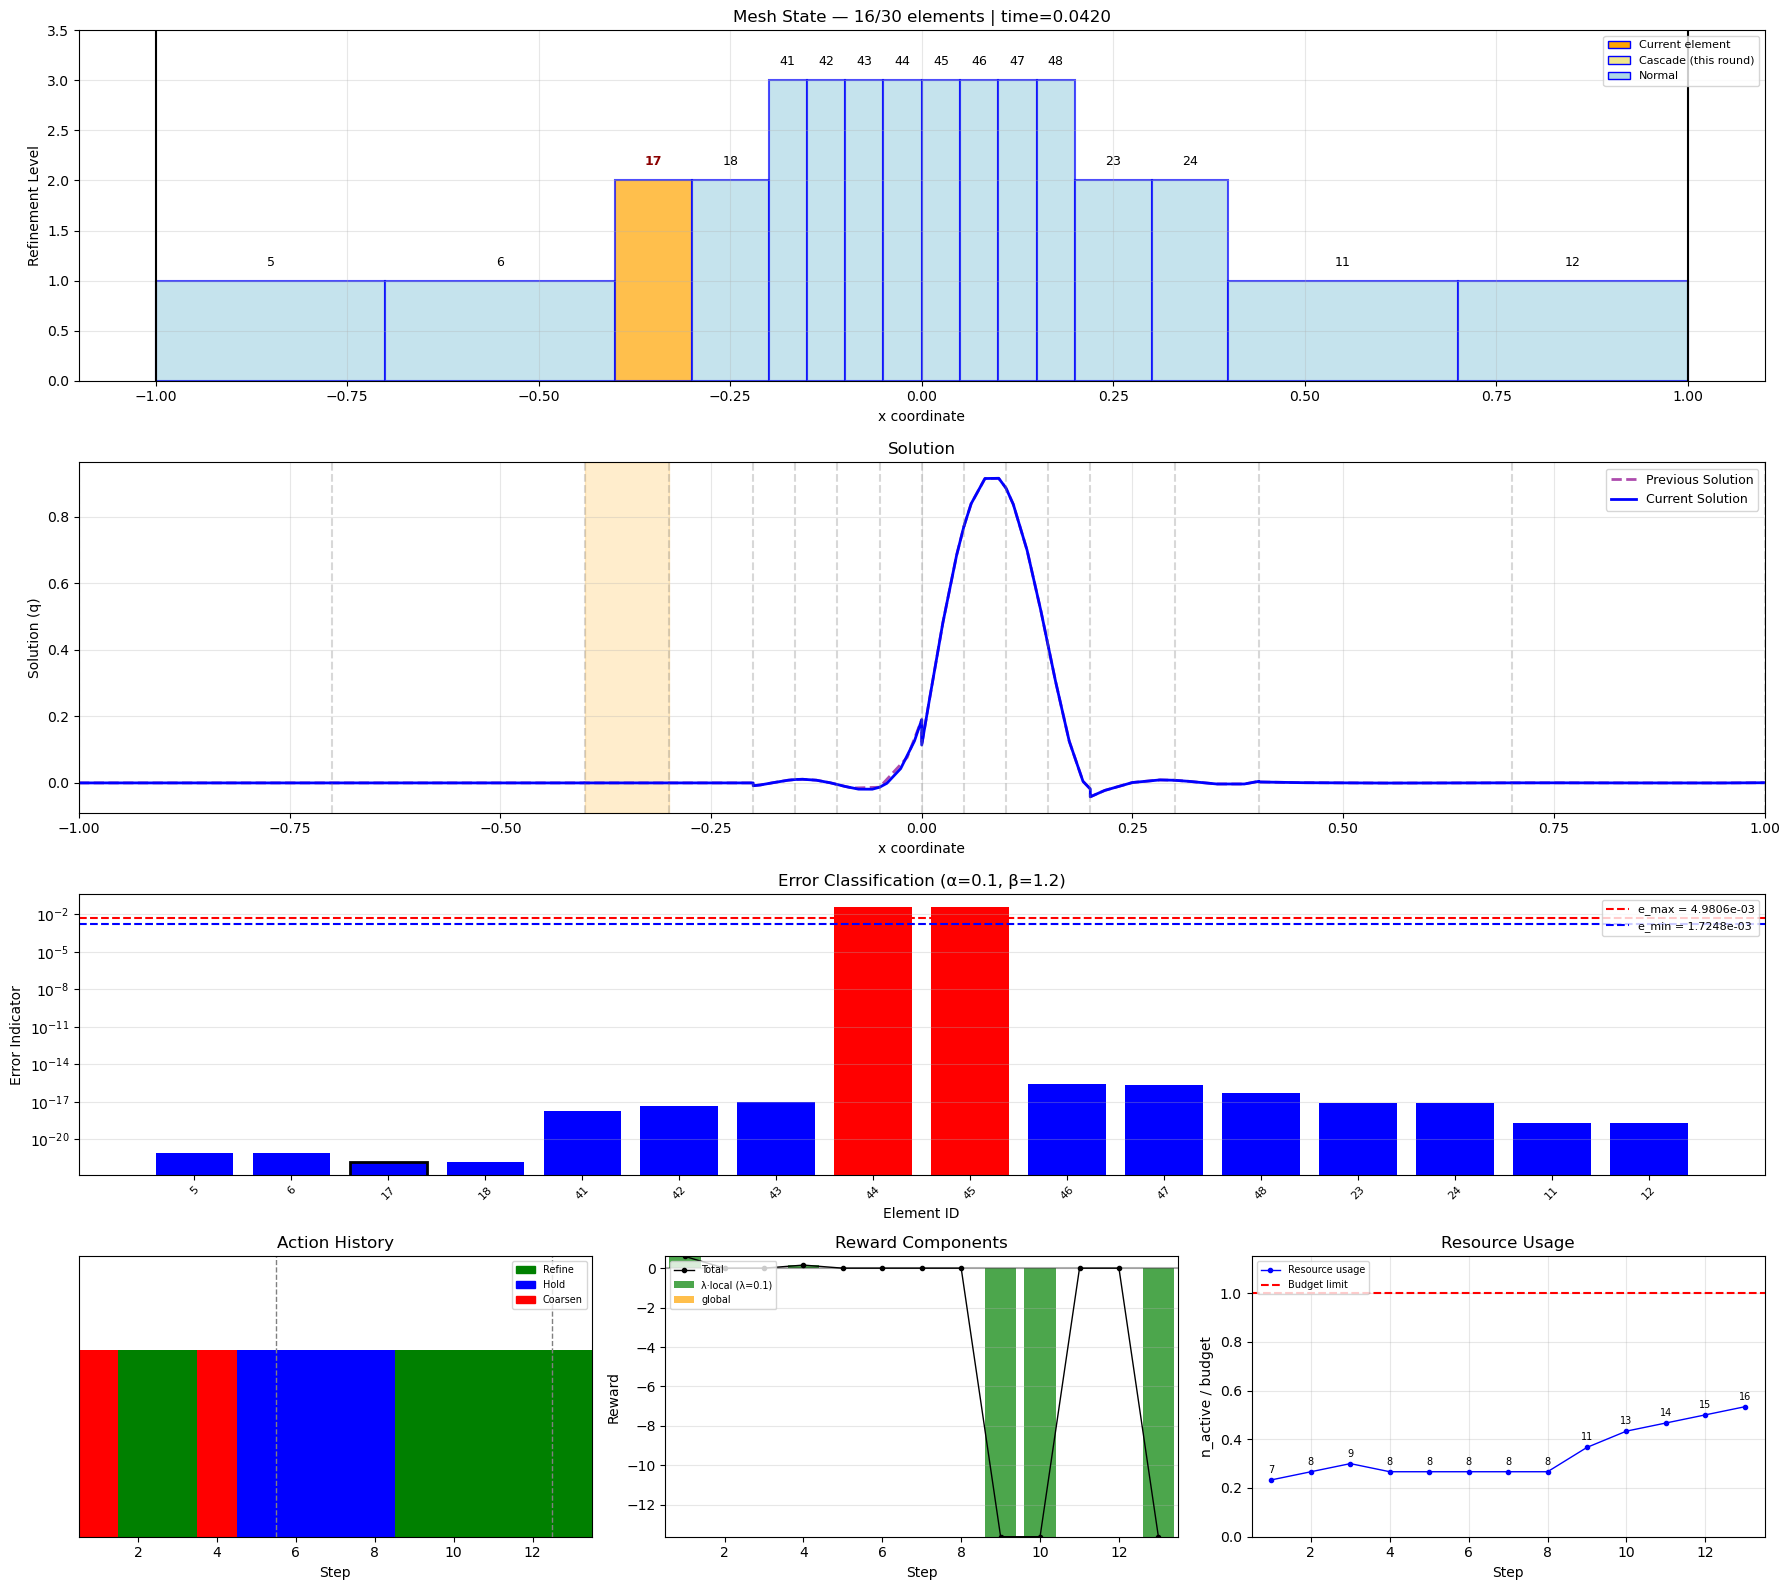

In [6]:
#==========================================================
#         ----------  Cell Five ------------
#==========================================================
"""
Cell 5: Create and Launch Interactive Tester

Instantiate the tester with desired parameters and display the interface.
Adjust parameters here or use the settings widgets in the UI.
"""
tester = InteractiveMultiroundTester(
    nop=4,                                              # Polynomial order
    initial_elements=np.array([-1, -0.5, 0, 0.5, 1]),  # 4 base elements on [-1, 1]
    max_level=3,                                        # Max refinement / rounds per interval
    element_budget=30,                                  # Soft cap on active elements
    alpha=0.1,                                          # Error tolerance (smaller → more refinement)
    beta=1.2,                                           # Hysteresis exponent (wider neutral zone)
    p_ur=10.0,                                          # Under-refinement penalty
    p_or=5.0,                                           # Over-refinement penalty
    p_cr=2.0,                                           # Correct coarsening reward
    lambda_local=0.1,                                   # Local-to-global reward weighting
    n_remesh=4,                                         # Remesh intervals per episode
    step_domain_fraction=0.05,                          # Fraction of domain per interval
    initial_refinement_level=1,                         # Start at level 1 (8 elements, can coarsen)
    icase=1,                                            # Gaussian pulse
)
tester.show_tester()

In [35]:
#==========================================================
#         ----------  Cell Six ------------
#==========================================================
"""
Cell 6: Manual SVG Save (Optional)

Use this if the Save SVG button doesn't capture the plot correctly,
or to save with a custom filename.
"""
# Save the current figure manually
if hasattr(tester, 'current_fig') and tester.current_fig is not None:
    tester.current_fig.savefig('multiround_amr_manual_save.svg', format='svg', bbox_inches='tight')
    print("Saved as multiround_amr_manual_save.svg")
else:
    print("No figure available. Run a step first.")

Saved as multiround_amr_manual_save.svg
